In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree

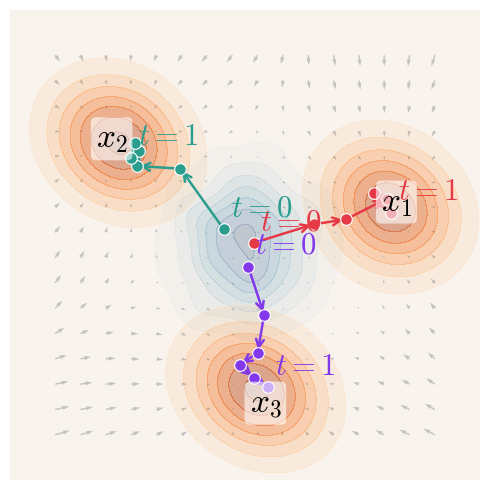

In [55]:
np.random.seed(42)
n = 600

# Source: standard Gaussian
source = np.random.randn(n, 2)

# Target: mixture of Gaussians
target = np.concatenate([
    np.random.randn(n // 3, 2) * 0.5 + [3.2,  0.8],
    np.random.randn(n // 3, 2) * 0.5 + [-2.8, 2.2],
    np.random.randn(n // 3, 2) * 0.5 + [0.3, -3.2],
])
target_clusters = [target[:n//3], target[n//3:2*n//3], target[2*n//3:]]

lim      = 5.2
data_lim = 4.2

# --- density estimation ---
xx, yy = np.mgrid[-lim:lim:200j, -lim:lim:200j]
pos = np.vstack([xx.ravel(), yy.ravel()])
Z_src = gaussian_kde(source.T)(pos).reshape(xx.shape)
Z_tgt = gaussian_kde(target.T)(pos).reshape(xx.shape)

# --- vector field ---
h = 1.8
gx = np.linspace(-data_lim, data_lim, 16)
gy = np.linspace(-data_lim, data_lim, 16)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])

d2 = ((target[None] - grid_pts[:, None])**2).sum(axis=2)
w  = np.exp(-d2 / (2*h**2));  w /= w.sum(axis=1, keepdims=True)
mean_tgt = (w[:, :, None] * target[None]).sum(axis=1)
flows = mean_tgt - grid_pts
U = flows[:, 0].reshape(GX.shape)
V = flows[:, 1].reshape(GX.shape)
mag = np.sqrt(U**2 + V**2);  U /= mag.max();  V /= mag.max()

# --- trajectory integration with per-step noise ---
def nw_velocity(x, tgt_samples, h=1.5):
    d2 = ((tgt_samples - x)**2).sum(axis=1)
    w  = np.exp(-d2 / (2*h**2));  w /= w.sum()
    return (w[:, None] * tgt_samples).sum(axis=0) - x

def euler_integrate(x0, tgt_samples, dt=0.55, n_steps=5, h=1.5, noise_scale=0.25):
    pts = [x0.copy()]
    x = x0.copy()
    for _ in range(n_steps):
        v = nw_velocity(x, tgt_samples, h)
        x = x + dt * v + np.random.randn(2) * noise_scale
        pts.append(x.copy())
    return np.array(pts)

cluster_centers = np.array([[3.2, 0.8], [-2.8, 2.2], [0.3, -3.2]])
traj_colors = ['#e63946', '#2a9d8f', '#8338ec']

src_near_origin = source[np.linalg.norm(source, axis=1) < 0.6]
trajectories = []
for center, tgt_k in zip(cluster_centers, target_clusters):
    dirs = src_near_origin / (np.linalg.norm(src_near_origin, axis=1, keepdims=True) + 1e-6)
    x0 = src_near_origin[np.argmax(dirs @ (center / np.linalg.norm(center)))]
    trajectories.append(euler_integrate(x0, tgt_k, dt=0.55, n_steps=5, h=1.5))

# --- plot ---
plt.rcParams['mathtext.fontset'] = 'cm'

fig, ax = plt.subplots(figsize=(5, 5), facecolor='white')

ax.contourf(xx, yy, Z_src, levels=8, cmap='Blues',   alpha=0.45, zorder=1)
ax.contourf(xx, yy, Z_tgt, levels=8, cmap='Oranges', alpha=0.45, zorder=1)

ax.quiver(GX, GY, U, V,
          color='#2d2d2d', alpha=0.25,
          angles='xy', scale_units='xy', scale=3,
          width=0.003, zorder=2)

# cluster labels
cluster_label_offsets = [(0.15, 0.15), (-0.15, 0.15), (0.15, -0.3)]
for k, (center, (dx, dy)) in enumerate(zip(cluster_centers, cluster_label_offsets)):
    ax.text(center[0] + dx, center[1] + dy, f"$x_{{{k+1}}}$",
            fontsize=24, color='black', ha='center', va='center',
            fontweight='bold', zorder=10,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.6))

n_steps = 5
offset = 0.15
for pts, color in zip(trajectories, traj_colors):
    for i in range(len(pts) - 1):
        d = pts[i + 1] - pts[i]
        d /= np.linalg.norm(d)
        ax.annotate("", xy=pts[i + 1], xytext=pts[i],
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8,
                                   mutation_scale=14),
                    zorder=4)

    for i, pt in enumerate(pts):
        ax.scatter(*pt, s=70, color=color, zorder=7, edgecolors='white', linewidths=0.8)
        if i == 0:
            ax.text(pt[0] + offset, pt[1] + offset, "$t=0$",
                    fontsize=22, color=color, zorder=10, ha='left', va='bottom')
        elif i == n_steps:
            ax.text(pt[0] + offset, pt[1] + offset, "$t=1$",
                    fontsize=22, color=color, zorder=10, ha='left', va='bottom')

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()
